In [126]:
!pip install numpy



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:


Data = pd.read_csv(
    r"C:\Users\POOJA\OneDrive\Desktop\Google-PlayStore-EDA\Google-PlayStore-EDA\Data\Raw_Data\googleplaystore.csv"
)

Data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.10,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.90,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.70,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.50,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.30,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [129]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [130]:
Data.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

# Handelled missing Values

<Axes: ylabel='Frequency'>

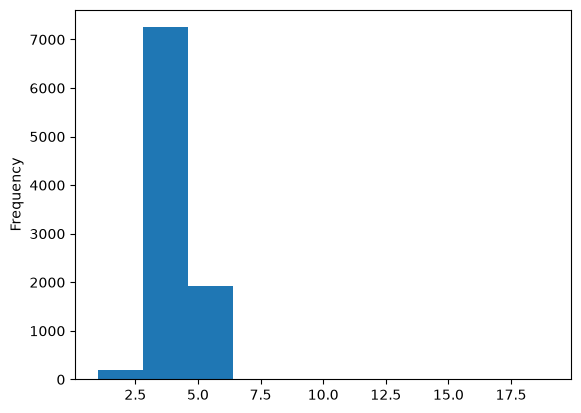

In [131]:
Data['Rating'].plot(kind='hist')

In [132]:
Data['Rating']=Data['Rating'].fillna(Data['Rating'].median())

In [133]:
Data['Type']=Data['Type'].fillna(Data['Type'].mode()[0])

In [134]:
Data['Content Rating']= Data['Content Rating'].fillna(Data['Content Rating'].mode()[0])

In [135]:
Data['Current Ver']=Data['Current Ver'].fillna(Data['Current Ver'].mode()[0])

In [136]:
Data['Android Ver'] = Data['Android Ver'].fillna(Data['Android Ver'].mode()[0])

In [137]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          10841 non-null  float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10841 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10841 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10841 non-null  str    
 12  Android Ver     10841 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [138]:
Data.drop(Data[Data['Reviews'] == '3.0M'].index,inplace=True)

In [139]:
Data['Reviews'] = Data['Reviews'].astype(int)

In [140]:
# Strip '$', remove surrounding whitespace, and convert to float
Data['Price'] = Data['Price'].str.replace('$', '', regex=False).str.strip().astype(float)

In [141]:
Data['Price'].unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [142]:
Data.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          10840 non-null  float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  str    
 5   Installs        10840 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10840 non-null  str    
 12  Android Ver     10840 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 1.2 MB


In [143]:
Data['Last Updated']

0         January 7, 2018
1        January 15, 2018
2          August 1, 2018
3            June 8, 2018
4           June 20, 2018
               ...       
10836       July 25, 2017
10837        July 6, 2018
10838    January 20, 2017
10839    January 19, 2015
10840       July 25, 2018
Name: Last Updated, Length: 10840, dtype: str

In [144]:
Data['Current Ver']

0                     1.0.0
1                     2.0.0
2                     1.2.4
3        Varies with device
4                       1.1
                ...        
10836                  1.48
10837                   1.0
10838                   1.0
10839    Varies with device
10840    Varies with device
Name: Current Ver, Length: 10840, dtype: str

In [145]:
Data.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          10840 non-null  float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  str    
 5   Installs        10840 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10840 non-null  str    
 12  Android Ver     10840 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 1.2 MB


In [146]:
Data.describe()

,Rating,Reviews,Price
count,10840.00,10840.00,10840.00
mean,4.21,444152.90,1.03
std,0.48,2927760.60,15.95
min,1.00,0.00,0.00
25%,4.10,38.00,0.00
50%,4.30,2094.00,0.00
75%,4.50,54775.50,0.00
max,5.00,78158306.00,400.00


In [147]:


Data = Data[Data['Android Ver'] != 'NaN'] 



In [148]:
# 2. Clean 'Price' and convert to float
Data['Price'] = pd.to_numeric(Data['Price'], errors='coerce')

In [149]:
# 3. Clean 'Installs' (remove '+' and ',') and convert to int
Data['Installs'] = Data['Installs'].str.replace('+', '', regex=False)
Data['Installs'] = Data['Installs'].str.replace(',', '', regex=False)
Data['Installs'] = pd.to_numeric(Data['Installs'], errors='coerce')

In [150]:
Data['Reviews'] = pd.to_numeric(Data['Reviews'], errors='coerce')



In [151]:
# 5. Clean 'Size' (convert megabytes/kilobytes to float MB)
def clean_size(size_str):
    if pd.isna(size_str) or size_str == 'Varies with device':
        return np.nan
    if 'M' in size_str:
        return float(size_str.replace('M', ''))
    if 'k' in size_str:
        return float(size_str.replace('k', '')) / 1024
    return np.nan

Data['Size'] = Data['Size'].apply(clean_size)

In [152]:
import numpy as np

# Format NumPy display to 2 decimal places instead of scientific notation
np.set_printoptions(suppress=True, precision=2)

# Or set pandas float display format
pd.set_option('display.float_format', lambda x: '%.2f' % x)
Data['Size'].unique()

array([ 19.  ,  14.  ,   8.7 ,  25.  ,   2.8 ,   5.6 ,  29.  ,  33.  ,
         3.1 ,  28.  ,  12.  ,  20.  ,  21.  ,  37.  ,   2.7 ,   5.5 ,
        17.  ,  39.  ,  31.  ,   4.2 ,   7.  ,  23.  ,   6.  ,   6.1 ,
         4.6 ,   9.2 ,   5.2 ,  11.  ,  24.  ,    nan,   9.4 ,  15.  ,
        10.  ,   1.2 ,  26.  ,   8.  ,   7.9 ,  56.  ,  57.  ,  35.  ,
        54.  ,   0.2 ,   3.6 ,   5.7 ,   8.6 ,   2.4 ,  27.  ,   2.5 ,
        16.  ,   3.4 ,   8.9 ,   3.9 ,   2.9 ,  38.  ,  32.  ,   5.4 ,
        18.  ,   1.1 ,   2.2 ,   4.5 ,   9.8 ,  52.  ,   9.  ,   6.7 ,
        30.  ,   2.6 ,   7.1 ,   3.7 ,  22.  ,   7.4 ,   6.4 ,   3.2 ,
         8.2 ,   9.9 ,   4.9 ,   9.5 ,   5.  ,   5.9 ,  13.  ,  73.  ,
         6.8 ,   3.5 ,   4.  ,   2.3 ,   7.2 ,   2.1 ,  42.  ,   7.3 ,
         9.1 ,  55.  ,   0.02,   6.5 ,   1.5 ,   7.5 ,  51.  ,  41.  ,
        48.  ,   8.5 ,  46.  ,   8.3 ,   4.3 ,   4.7 ,   3.3 ,  40.  ,
         7.8 ,   8.8 ,   6.6 ,   5.1 ,  61.  ,  66.  ,   0.08,   8.4 ,
      

<Axes: ylabel='Frequency'>

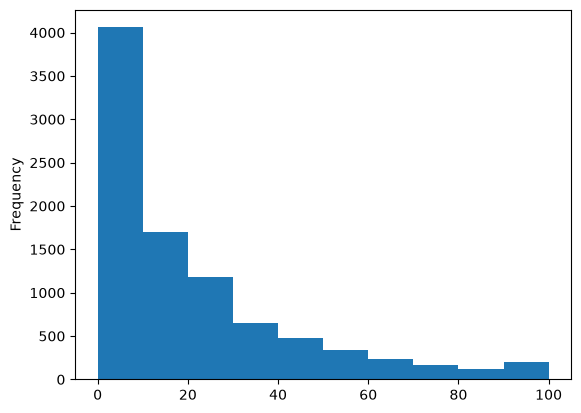

In [153]:
Data['Size'].plot(kind='hist')

In [154]:
Data['Size']= Data['Size'].fillna(Data['Size'].median())

In [155]:
Data.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [156]:
# 1. Ensure Reviews is numeric
Data['Reviews'] = pd.to_numeric(Data['Reviews'], errors='coerce')

# 2. Sort by Reviews descending so the most recent/reviewed entry is first
Data = Data.sort_values(by='Reviews', ascending=False)

# 3. Drop duplicate apps, keeping only the top entry
Data = Data.drop_duplicates(subset=['App'], keep='first')

# 4. Reset index numbers
Data = Data.reset_index(drop=True)

In [157]:
Data.head(40
          )

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Facebook,SOCIAL,4.10,78158306,13.00,1000000000,Free,0.00,Teen,Social,"August 3, 2018",Varies with device,Varies with device
1,WhatsApp Messenger,COMMUNICATION,4.40,69119316,13.00,1000000000,Free,0.00,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2,Instagram,SOCIAL,4.50,66577446,13.00,1000000000,Free,0.00,Teen,Social,"July 31, 2018",Varies with device,Varies with device
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.00,56646578,13.00,1000000000,Free,0.00,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
4,Clash of Clans,GAME,4.60,44893888,98.00,100000000,Free,0.00,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up
5,Clean Master- Space Cleaner & Antivirus,TOOLS,4.70,42916526,13.00,500000000,Free,0.00,Everyone,Tools,"August 3, 2018",Varies with device,Varies with device
6,Subway Surfers,GAME,4.50,27725352,76.00,1000000000,Free,0.00,Everyone 10+,Arcade,"July 12, 2018",1.90.0,4.1 and up
7,YouTube,VIDEO_PLAYERS,4.30,25655305,13.00,1000000000,Free,0.00,Teen,Video Players & Editors,"August 2, 2018",Varies with device,Varies with device
8,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,4.70,24900999,13.00,500000000,Free,0.00,Everyone,Tools,"August 4, 2018",4.6.6,Varies with device
9,Clash Royale,GAME,4.60,23136735,97.00,100000000,Free,0.00,Everyone 10+,Strategy,"June 27, 2018",2.3.2,4.1 and up


In [158]:
Data.to_csv(r'C:\Users\POOJA\OneDrive\Desktop\Google-PlayStore-EDA\Google-PlayStore-EDA\Data\Clean_data\CleanData.csv')